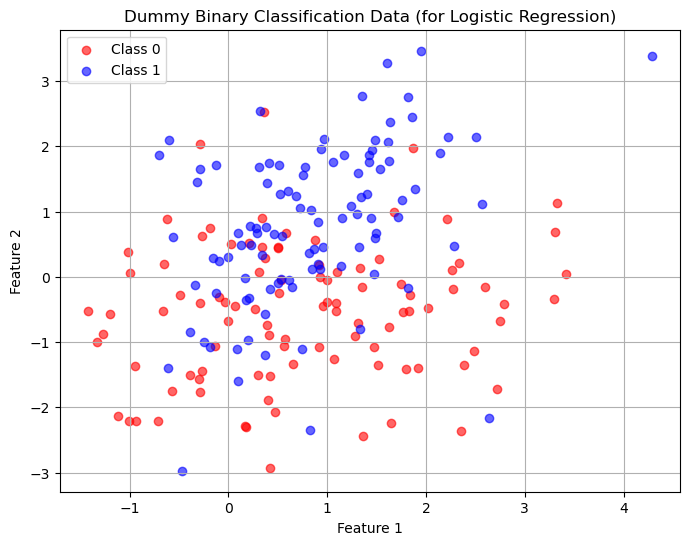

Features shape: (200, 2)
Target shape: (200,)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

#data splitting
x, X_test, y, y_test = train_test_split(
    x, y, test_size=0.4, random_state=42, stratify=y
)

In [4]:
#function for calculating information
def information_gain(x,y,f_name):

    thresholds=np.unique(x[:,f_name])
    x_right_branch=[]
    y_right_branch=[]
    x_left_branch=[]
    y_left_branch=[]
    
    temp_best_x_right=[]
    temp_best_y_right=[]
    temp_best_x_left=[]
    temp_best_y_left=[]
    
    total=len(y)
    unique_classes=np.unique(y)
    n_probs=[]
    
    for n_class in  unique_classes :
        p1 = (y == n_class).sum() / total
        n_probs.append(p1) 
    n_probs = np.array(n_probs)
    H_root = np.sum(-n_probs*np.log2(n_probs))
    
    H_dn = 0
    best_threshold=None
    best_ig = -np.inf
    
    for n in thresholds:
        if n==thresholds[-1]:
            k=n-0.00001
            left_b_x = x[x[:,f_name]<=k]
            left_b_y = y[x[:,f_name]<=k]
            
            right_b_x = x[x[:,f_name]>k]
            right_b_y = y[x[:,f_name]>k]
        else:    
            left_b_x = x[x[:,f_name]<=n]
            left_b_y = y[x[:,f_name]<=n]
            
            right_b_x = x[x[:,f_name]>n]
            right_b_y = y[x[:,f_name]>n]
            
        x_left_branch.append(left_b_x)
        y_left_branch.append(left_b_y)
        
        x_right_branch.append(right_b_x)
        y_right_branch.append(right_b_y)
        
        left_m = len(left_b_x)
        right_m=len(right_b_x)
        
        left_u = np.unique(left_b_y)
        right_u=np.unique(right_b_y)
        
        n_probs_left = []
        n_probs_right=[]
        
        max_threshold=[]
        
        for n_class in left_u:
            p1 = np.sum(left_b_y == n_class) / left_m
            n_probs_left.append(p1)
    
        for n_class in right_u:
            p1 = np.sum(right_b_y == n_class) / right_m
            n_probs_right.append(p1)
                
        n_probs_left = np.array(n_probs_left)
        n_probs_right = np.array(n_probs_right)
    
    
        H_dn = len(left_b_y)/total * np.sum(-n_probs_left*np.log2(n_probs_left))+len(right_b_y)/total * np.sum(-n_probs_right*np.log2(n_probs_right))
        ig = H_root -  H_dn
        if ig > best_ig:
            best_ig = ig
            best_threshold = n
            temp_best_x_right= right_b_x
            temp_best_y_right= right_b_y
            temp_best_x_left=  left_b_x
            temp_best_y_left=  left_b_y
    return best_threshold, best_ig ,[temp_best_x_left,temp_best_x_right ],[temp_best_y_left,temp_best_y_right]

number_classes = len(np.unique(y))
depth=5
best_feature = None
best_x_branchs,best_y_branchs= [x], [y]
nf=len(x[0])

tree = {}##################
root_node = []

for d in range(depth):
    next_x_branches = []
    next_y_branches = []
    
    for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_branchs, best_y_branchs):
        IG_value = -np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        decision = None
        y_pred = None
        best_threshold=None
        for f_name in range(0,nf):
            threshold,IG, x_csvs_branch, y_csvs_branch= information_gain(best_x_csvs_branch, best_y_csvs_branch, f_name)
            print(IG)
            if IG>IG_value:
                IG_value = IG
                if IG>0:
                    temp_best_x_csvs_branch = x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    best_feature = f_name
                    best_threshold=threshold
                else:
                    values, counts = np.unique(best_y_csvs_branch, return_counts=True)
                    y_pred = values[np.argmax(counts)]
        print(best_feature, IG_value)
        node_id = id(best_x_csvs_branch)##################
        root_node.append(node_id)
        tree[node_id] = {             ###################
            "feature": best_feature,
            "ig": IG_value,
            "children": [],
            "threshold":best_threshold,
            "pred" :y_pred,
        } #####################################
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x in temp_best_x_csvs_branch: ###########
                tree[node_id]["children"].append(id(child_x))    ###########
            
    best_x_branchs = next_x_branches
    best_y_branchs = next_y_branches
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_branchs, best_y_branchs):
            values, counts = np.unique(best_y_csvs_branch, return_counts=True)
            y_pred = values[np.argmax(counts)]
            node_id = id(best_x_csvs_branch)##################
            tree[node_id] = {             ###################
                "feature": None,
                "ig": None,
                "children": [],
                "pred": y_pred
            } #####################################
y_pred = []
for i in range(len(X_test)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None :
            feature_name = search
            value=X_test[i,feature_name]
            if value<=tree[nid]["threshold"]:
                children_id=0
            else:
                children_id=1
            nid = tree[nid]["children"][children_id]
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y_test

accuracy = np.mean(y_true_labels == y_pred) * 100
accuracy    


0.09101787862171862
0.16520766441438106
1 0.16520766441438106
0.09099570292543468
0.05545880854573637
0 0.09099570292543468
0.08543059251183494
0.17523196051238366
1 0.17523196051238366
0.11268364362703709
0.06789165106609873
0 0.11268364362703709
0.0
0.0
None 0.0
0.0
0.0
None 0.0
0.19350684337293445
0.44643934467101554
1 0.44643934467101554
0.0
0.0
None 0.0
0.020710670978715373
0.046376469413387134
1 0.046376469413387134
0.0
0.0
None 0.0
0.2935644431995964
0.13792538097003
0 0.2935644431995964
0.20641062172164726
0.14602129137221942
0 0.20641062172164726
0.07898214060026854
0.03725099887509298
0 0.07898214060026854
1.0
1.0
0 1.0
0.0
0.0
None 0.0


np.float64(81.25)

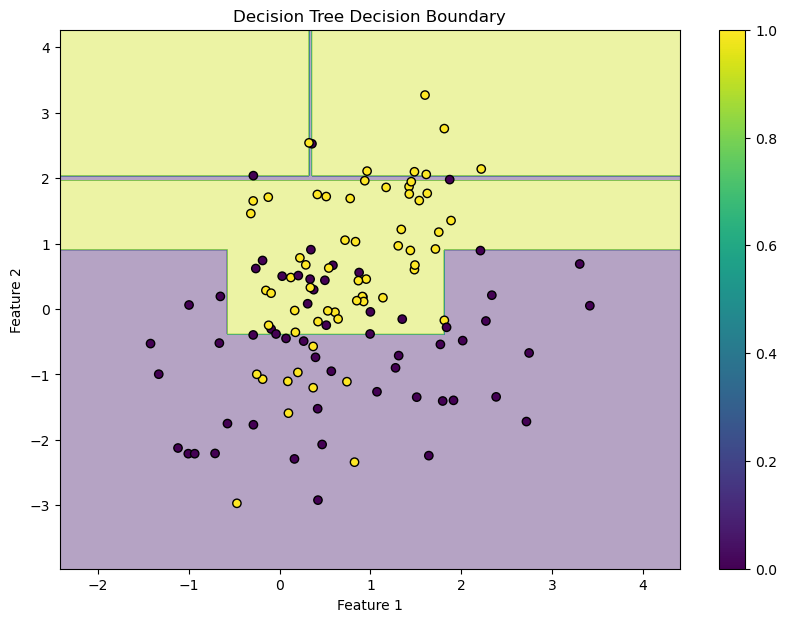

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Create mesh grid
# ==========================

x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# ==========================
# Predict on grid
# ==========================

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = []

for point in grid_points:

    nid = root_node[0]

    while True:

        feature = tree[nid]["feature"]

        if feature is not None:

            value = point[feature]

            if value <= tree[nid]["threshold"]:
                nid = tree[nid]["children"][0]

            else:
                nid = tree[nid]["children"][1]

        else:

            Z.append(tree[nid]["pred"])
            break

Z = np.array(Z)
Z = Z.reshape(xx.shape)

# ==========================
# Plot Decision Boundary
# ==========================

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.4)

scatter = plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    edgecolors='black'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundary")

plt.colorbar(scatter)
plt.show()

In [6]:
tree

{2306044248784: {'feature': 1,
  'ig': np.float64(0.16520766441438106),
  'children': [2306045335984, 2306045336176],
  'threshold': np.float64(0.9068843220944873),
  'pred': None},
 2306045335984: {'feature': 0,
  'ig': np.float64(0.09099570292543468),
  'children': [2306045299280, 2306045302352],
  'threshold': np.float64(1.8143881315781485),
  'pred': None},
 2306045336176: {'feature': 1,
  'ig': np.float64(0.17523196051238366),
  'children': [2306045333872, 2306045339152],
  'threshold': np.float64(1.9608450630045966),
  'pred': None},
 2306045299280: {'feature': 0,
  'ig': np.float64(0.11268364362703709),
  'children': [2306045335216, 2306045339920],
  'threshold': np.float64(-0.5746856027104124),
  'pred': None},
 2306045302352: {'feature': None,
  'ig': np.float64(0.0),
  'children': [],
  'threshold': None,
  'pred': np.int64(0)},
 2306045333872: {'feature': None,
  'ig': np.float64(0.0),
  'children': [],
  'threshold': None,
  'pred': np.int64(1)},
 2306045339152: {'feature':

In [7]:
y_pred = []
for i in range(len(X_test)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None :
            feature_name = search
            value=X_test[i,feature_name]
            if value<=tree[nid]["threshold"]:
                children_id=0
            else:
                children_id=1
            nid = tree[nid]["children"][children_id]
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y_test

accuracy = np.mean(y_true_labels == y_pred) * 100
accuracy   

np.float64(81.25)